<a href="https://colab.research.google.com/github/tejaal31/Tugas-Week-8-CNN-Streamlit-App/blob/main/TK2_W8_S23_R0_CNN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Kelompok ke-2 Week 8
## TEJA LESMANA (2902694521)
## Optimasi Model CNN dan Implementasi Aplikasi Sederhana

Notebook ini digunakan untuk membuat model CNN pada dataset CIFAR-10, melakukan optimasi sederhana menggunakan hyperparameter tuning, menambahkan Batch Normalization dan Dropout, melakukan evaluasi akhir, serta menyimpan model untuk digunakan pada aplikasi Streamlit.

## 1. Import Library

In [1]:
import sys
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Loader alternatif CIFAR-10 dari Hugging Face, karena sumber resmi University of Toronto sedang down.
try:
    from datasets import load_dataset
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'datasets', '-q'])
    from datasets import load_dataset

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from PIL import Image


## 2. Load Dataset dan Preprocessing

Dataset yang digunakan adalah CIFAR-10. Karena server resmi University of Toronto sedang tidak tersedia dan `tensorflow_datasets` juga mengambil file dari server yang sama, notebook ini memakai mirror dari Hugging Face `datasets` sebagai alternatif. Dataset tetap CIFAR-10, sehingga tetap sesuai dengan kebutuhan tugas.

In [2]:
# Load dataset CIFAR-10 dari Hugging Face mirror
# Ini menghindari error 503 dari www.cs.toronto.edu.
dataset = load_dataset('cifar10')

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

def convert_split(split):
    images = []
    labels = []
    for item in dataset[split]:
        img = item['img'].convert('RGB').resize((32, 32))
        images.append(np.asarray(img, dtype=np.float32) / 255.0)
        labels.append(item['label'])
    return np.array(images, dtype=np.float32), np.array(labels)

X_train, y_train = convert_split('train')
X_test, y_test = convert_split('test')

# One-hot encoding label
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print('Jumlah data train:', X_train.shape)
print('Jumlah data test :', X_test.shape)
print('Jumlah kelas     :', num_classes)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Jumlah data train: (50000, 32, 32, 3)
Jumlah data test : (10000, 32, 32, 3)
Jumlah kelas     : 10


## 3. Menampilkan Contoh Dataset

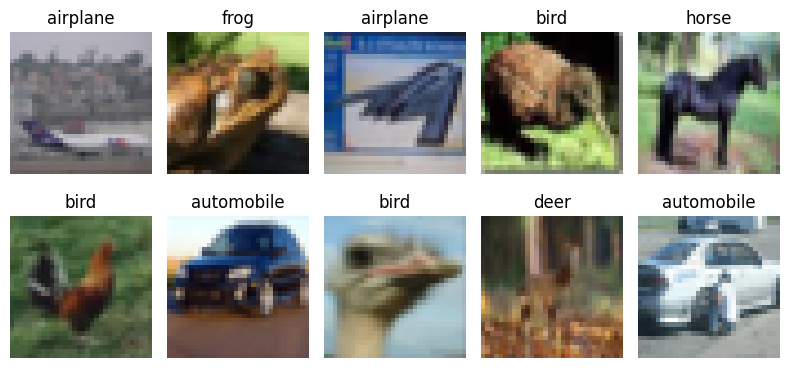

In [3]:
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Fungsi Membuat Model CNN

Model menggunakan Conv2D, BatchNormalization, MaxPooling2D, Dropout, dan Dense. Batch normalization digunakan untuk membantu proses training lebih stabil, sedangkan dropout digunakan untuk mengurangi overfitting.

In [4]:
def build_cnn_model(filters=(32, 64, 128), dense_units=128, dropout_rate=0.5, learning_rate=0.001):
    model = Sequential([
        Input(shape=(32, 32, 3)),

        Conv2D(filters[0], (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(filters[1], (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(filters[2], (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(dense_units, activation="relu"),
        Dropout(dropout_rate),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 5. Hyperparameter Tuning Sederhana

Pada bagian ini dilakukan percobaan beberapa kombinasi hyperparameter. Parameter yang diuji adalah jumlah filter, jumlah neuron Dense, dropout rate, dan learning rate.

In [5]:
configs = [
    {"name": "Model A", "filters": (32, 64, 128), "dense_units": 128, "dropout_rate": 0.4, "learning_rate": 0.001},
    {"name": "Model B", "filters": (64, 128, 256), "dense_units": 256, "dropout_rate": 0.5, "learning_rate": 0.001},
    {"name": "Model C", "filters": (32, 64, 128), "dense_units": 256, "dropout_rate": 0.3, "learning_rate": 0.0005},
]

TUNING_EPOCHS = 3
BATCH_SIZE = 64

results = []

for cfg in configs:
    print("Training", cfg["name"])
    model_temp = build_cnn_model(
        filters=cfg["filters"],
        dense_units=cfg["dense_units"],
        dropout_rate=cfg["dropout_rate"],
        learning_rate=cfg["learning_rate"]
    )

    history_temp = model_temp.fit(
        X_train,
        y_train_cat,
        epochs=TUNING_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_test, y_test_cat),
        verbose=1
    )

    val_acc = max(history_temp.history["val_accuracy"])
    results.append({"config": cfg, "val_accuracy": val_acc})
    print(cfg["name"], "Validation Accuracy Terbaik:", round(val_acc, 4))
    print("-" * 50)

Training Model A
Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 167s 207ms/step - accuracy: 0.4475 - loss: 1.5560 - val_accuracy: 0.5704 - val_loss: 1.2046
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 192s 195ms/step - accuracy: 0.6025 - loss: 1.1334 - val_accuracy: 0.6083 - val_loss: 1.1537
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 151s 193ms/step - accuracy: 0.6665 - loss: 0.9603 - val_accuracy: 0.6996 - val_loss: 0.8612
Model A Validation Accuracy Terbaik: 0.6996
--------------------------------------------------
Training Model B
Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 458s 582ms/step - accuracy: 0.4398 - loss: 1.5728 - val_accuracy: 0.5096 - val_loss: 1.3618
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 433s 554ms/step - accuracy: 0.5928 - loss: 1.1539 - val_accuracy: 0.6434 - val_loss: 1.0300
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 441s 552ms/step - accuracy: 0.6663 - loss: 0.9693 - val_accuracy: 0.6847 - val_loss: 0.9404
Model B Validation Accuracy Terbaik: 0.6847
-----------------------------------------

## 6. Menentukan Model Terbaik

In [6]:
best_result = max(results, key=lambda x: x["val_accuracy"])
best_config = best_result["config"]

print("Konfigurasi terbaik:")
print(best_config)
print("Validation accuracy terbaik:", round(best_result["val_accuracy"], 4))

Konfigurasi terbaik:
{'name': 'Model C', 'filters': (32, 64, 128), 'dense_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.0005}
Validation accuracy terbaik: 0.7149


## 7. Training Model Final

Model final dibuat menggunakan konfigurasi terbaik dari hasil tuning.

In [7]:
FINAL_EPOCHS = 10

final_model = build_cnn_model(
    filters=best_config["filters"],
    dense_units=best_config["dense_units"],
    dropout_rate=best_config["dropout_rate"],
    learning_rate=best_config["learning_rate"]
)

final_model.summary()

history = final_model.fit(
    X_train,
    y_train_cat,
    epochs=FINAL_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 165s 208ms/step - accuracy: 0.5116 - loss: 1.3922 - val_accuracy: 0.6127 - val_loss: 1.1009
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 164s 209ms/step - accuracy: 0.6576 - loss: 0.9771 - val_accuracy: 0.6581 - val_loss: 0.9779
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 161s 206ms/step - accuracy: 0.7196 - loss: 0.8022 - val_accuracy: 0.6325 - val_loss: 1.0898
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 207ms/step - accuracy: 0.7638 - loss: 0.6689 - val_accuracy: 0.7199 - val_loss: 0.8195
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 199s 204ms/step - accuracy: 0.7980 - loss: 0.5738 - val_accuracy: 0.7265 - val_loss: 0.8146
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 160s 205ms/step - accuracy: 0.8287 - loss: 0.4828 - val_accuracy: 0.6805 - val_loss: 1.0011
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 163s 208ms/step - accuracy: 0.8544 - loss: 0.4085 - val_accuracy: 0.7537 - val_loss: 0.7897
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 201s 207ms/step - accuracy: 0.8779 -

## 8. Evaluasi Akhir Model

In [8]:
loss, accuracy = final_model.evaluate(X_test, y_test_cat, verbose=0)

print("Hasil Evaluasi Akhir")
print(f"Loss    : {loss:.4f}")
print(f"Akurasi : {accuracy:.2%}")

Hasil Evaluasi Akhir
Loss    : 0.8485
Akurasi : 76.56%


## 9. Grafik Akurasi dan Loss

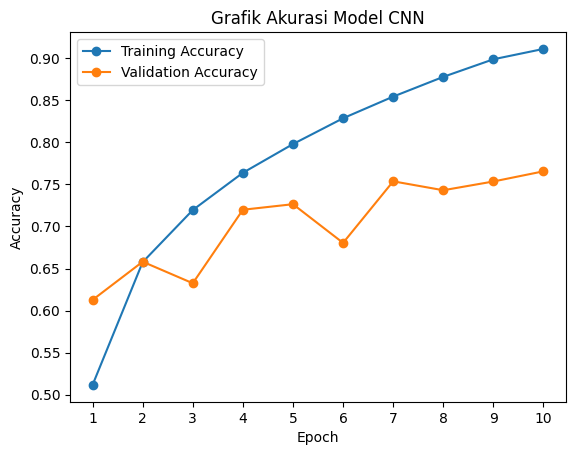

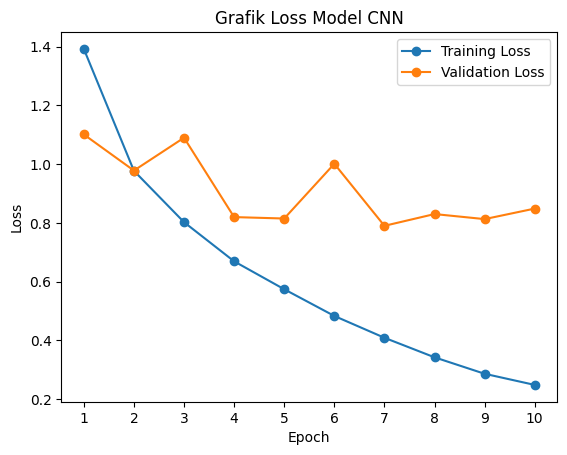

In [9]:
epochs = range(1, len(history.history["accuracy"]) + 1)

plt.plot(epochs, history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(epochs, history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Grafik Akurasi Model CNN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.show()

plt.plot(epochs, history.history["loss"], marker="o", label="Training Loss")
plt.plot(epochs, history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Grafik Loss Model CNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

## 10. Testing Prediksi pada Data Test

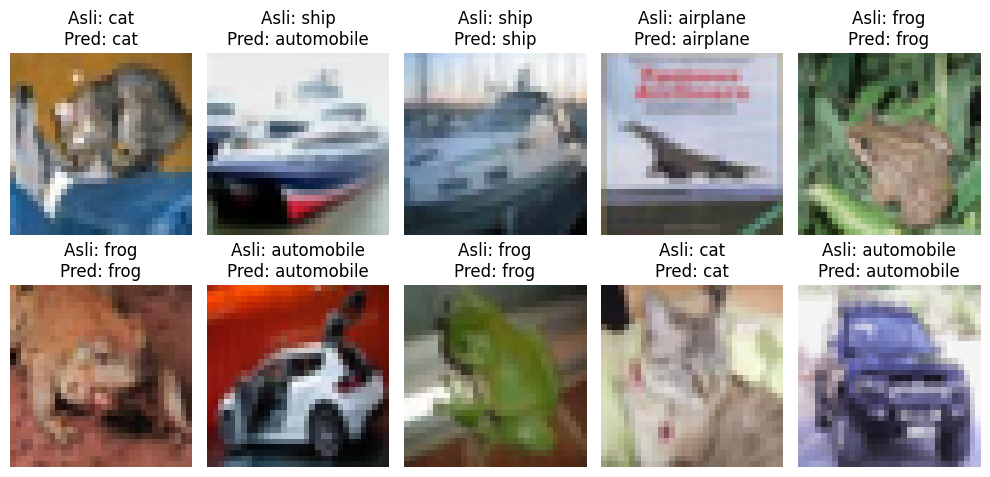

In [10]:
predictions = final_model.predict(X_test[:10], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = y_test[:10].flatten()

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i])
    plt.title(f"Asli: {class_names[true_labels[i]]}\nPred: {class_names[predicted_labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## 11. Simpan Model

Model disimpan agar dapat digunakan pada aplikasi Streamlit.

In [11]:
final_model.save("cnn_cifar10_optimized.keras")
print("Model berhasil disimpan dengan nama cnn_cifar10_optimized.keras")

Model berhasil disimpan dengan nama cnn_cifar10_optimized.keras
